# Level Detection Workbench

This notebook is a staged workbench for the hierarchy workflow.

It is meant to answer three questions in order:

1. Do the reviewed outputs look sane?
2. Does the reviewed network pass the directed-graph checks?
3. What bifurcation-confluence units and summary metrics do we get if the graph is valid?

The notebook is intentionally a validation notebook first and a metrics notebook second.

In [1]:
from pathlib import Path
import json
import sys
from importlib import reload

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

candidate_roots = [Path.cwd().resolve()]
candidate_roots.extend(candidate_roots[0].parents)
REPO_ROOT = next(path for path in candidate_roots if (path / "hierarchy_level_definition").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import hierarchy_level_definition.metrics.unit_metrics as unit_metrics_module
import hierarchy_level_definition.metrics as metrics_package
reload(unit_metrics_module)
reload(metrics_package)

from hierarchy_level_definition.graph_building.directed_network_checks import analyze_reviewed_network
from hierarchy_level_definition.unit_detection.bifurcation_confluence_units import analyze_network
from hierarchy_level_definition.metrics import compute_unit_metrics, summarize_by_hierarchy_level
from hierarchy_level_definition.metrics.unit_metrics import compute_unit_metrics_from_units

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

REPO_ROOT


PosixPath('/Users/6256481/Code/river-hierarchy')

## 1. Review Output Inspection

Pick a reviewed example and inspect the saved link/node files before building the graph.

In [2]:
network_name = "sarl_03"

review_dir = REPO_ROOT / "hierarchy_level_definition" / "manual_review" / "outputs" / network_name
links_path = review_dir / "directed_links.gpkg"
nodes_path = review_dir / "reviewed_nodes.gpkg"

pd.Series(
    {
        "network_name": network_name,
        "review_dir": str(review_dir),
        "links_path_exists": links_path.exists(),
        "nodes_path_exists": nodes_path.exists(),
        "links_path": str(links_path),
        "nodes_path": str(nodes_path),
    }
)

network_name                                                   sarl_03
review_dir           /Users/6256481/Code/river-hierarchy/hierarchy_...
links_path_exists                                                 True
nodes_path_exists                                                 True
links_path           /Users/6256481/Code/river-hierarchy/hierarchy_...
nodes_path           /Users/6256481/Code/river-hierarchy/hierarchy_...
dtype: object

# 1.5

In [41]:
if not links_path.exists() or not nodes_path.exists():
    raise FileNotFoundError("Reviewed links/nodes files are missing for the selected network.")

links = gpd.read_file(links_path)
nodes = gpd.read_file(nodes_path)

print(f"links: {len(links)} rows")
print(f"nodes: {len(nodes)} rows")
print("link columns:", list(links.columns))
print("node columns:", list(nodes.columns))

display(links.head())
display(nodes.head())

links: 82 rows
nodes: 56 rows
link columns: ['id_link', 'idx_link', 'id_nodes', 'n_nodes', 'id_us_node', 'id_ds_node', 'is_inlet', 'is_outlet', 'type_io', 'schema_rg', 'link_conn', 'wid_pix', 'len', 'wid', 'wid_adj', 'wid_med', 'len_adj', 'sinuosity', 'manual_direction_reviewed', 'manual_us_node', 'manual_ds_node', 'geometry_reversed_manual', 'geometry']
node columns: ['id_node', 'idx_node', 'id_links', 'n_links', 'is_inlet', 'is_outlet', 'type_io', 'schema_rg', 'source_is_inlet', 'source_is_outlet', 'manual_role', 'node_role_reviewed', 'geometry']


,id_link,idx_link,id_nodes,n_nodes,id_us_node,id_ds_node,is_inlet,is_outlet,type_io,schema_rg,link_conn,wid_pix,len,wid,wid_adj,wid_med,len_adj,sinuosity,manual_direction_reviewed,manual_us_node,manual_ds_node,geometry_reversed_manual,geometry
0,48,"692006, 692005, 692004, 692003, 692002, 692001...","31, 34",2,31,34,False,False,neither,rg-v1,"52, 49, 45, 47","158.97096087236284, 125.67757954554364, 112.40...",1186.290687,170.307021,138.428184,125.677580,847.065180,1.082040,True,31,34,True,"LINESTRING (243310.493 7600250.068, 243338.595..."
1,52,"723019, 724836, 726653, 728470, 728469, 728468...","34, 36",2,34,36,False,False,neither,rg-v1,"53, 48, 49, 54","553.5523169568283, 530.2342889776091, 505.8425...",3321.242875,242.219392,227.309886,224.818889,2925.812646,1.076765,True,34,36,True,"LINESTRING (244265.973 7599772.328, 244294.075..."
2,49,"662905, 664724, 666542, 668361, 670179, 671998...","32, 34",2,32,34,False,False,neither,rg-v1,"48, 46, 52, 47","281.0236111114727, 231.73800638102054, 224.818...",666.810634,139.430166,120.659701,125.677580,435.172969,1.151012,True,32,34,False,"LINESTRING (243900.642 7600221.965, 243928.745..."
3,47,"661066, 659249, 657432, 657433, 659252, 659253...","31, 32",2,31,32,False,False,neither,rg-v1,"48, 46, 49, 45","428.0424119231023, 405.29801579138655, 341.879...",648.351479,282.368219,247.233916,241.546583,248.099647,1.070604,True,31,32,False,"LINESTRING (243310.493 7600250.068, 243338.595..."
4,54,"723019, 723020, 724839, 724840, 726659, 726660...","36, 37",2,36,37,False,False,neither,rg-v1,"53, 52, 55, 56","553.5523169568283, 605.3433842125422, 562.0472...",812.144043,531.186763,490.359498,502.710318,208.356907,1.048528,True,36,37,False,"LINESTRING (247272.926 7599294.587, 247301.028..."


,id_node,idx_node,id_links,n_links,is_inlet,is_outlet,type_io,schema_rg,source_is_inlet,source_is_outlet,manual_role,node_role_reviewed,geometry
0,34,692006,"48, 52, 49",3,False,False,neither,rg-v1,False,False,internal,True,POINT (244265.973 7599772.328)
1,31,661066,"48, 47, 45",3,False,False,neither,rg-v1,False,False,internal,True,POINT (243310.493 7600250.068)
2,36,723019,"52, 54, 53",3,False,False,neither,rg-v1,False,False,internal,True,POINT (247272.926 7599294.587)
3,32,662905,"49, 46, 47",3,False,False,neither,rg-v1,False,False,internal,True,POINT (243900.642 7600221.965)
4,37,735771,"54, 55, 56",3,False,False,neither,rg-v1,False,False,internal,True,POINT (248003.587 7599097.871)


In [42]:
review_summary = pd.Series(
    {
        "n_links": len(links),
        "n_nodes": len(nodes),
        "n_flagged_inlets": int(nodes["is_inlet"].fillna(False).astype(bool).sum()) if "is_inlet" in nodes.columns else None,
        "n_flagged_outlets": int(nodes["is_outlet"].fillna(False).astype(bool).sum()) if "is_outlet" in nodes.columns else None,
        "n_reversed_geometries": int(links["geometry_reversed_manual"].fillna(False).astype(bool).sum()) if "geometry_reversed_manual" in links.columns else None,
        "manual_role_counts": nodes["manual_role"].value_counts(dropna=False).to_dict() if "manual_role" in nodes.columns else None,
    }
)

review_summary

n_links                                                         82
n_nodes                                                         56
n_flagged_inlets                                                 1
n_flagged_outlets                                                1
n_reversed_geometries                                           45
manual_role_counts       {'internal': 54, 'outlet': 1, 'inlet': 1}
dtype: object

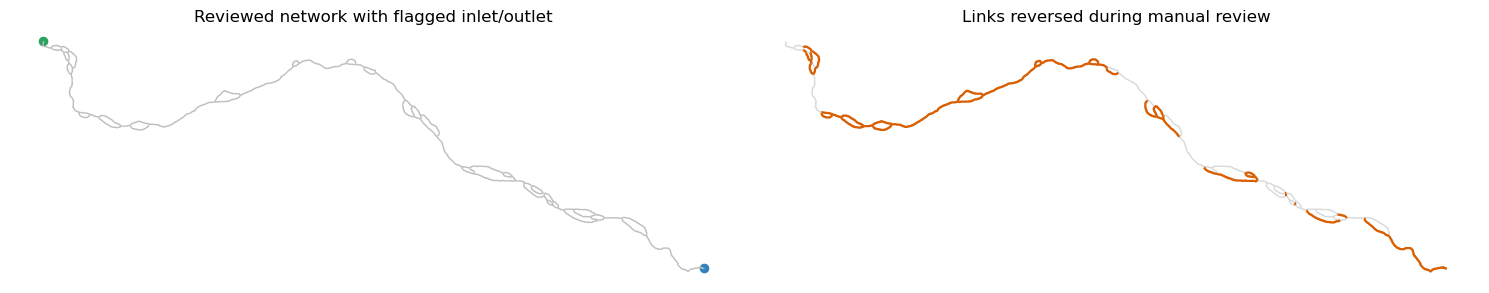

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

links.plot(ax=axes[0], color="0.75", linewidth=1)
if "is_inlet" in nodes.columns:
    nodes.loc[nodes["is_inlet"].fillna(False).astype(bool)].plot(ax=axes[0], color="#2ca25f", markersize=35)
if "is_outlet" in nodes.columns:
    nodes.loc[nodes["is_outlet"].fillna(False).astype(bool)].plot(ax=axes[0], color="#3182bd", markersize=35)
axes[0].set_title("Reviewed network with flagged inlet/outlet")
axes[0].set_axis_off()

links.plot(ax=axes[1], color="0.85", linewidth=1)
if "geometry_reversed_manual" in links.columns:
    reversed_links = links.loc[links["geometry_reversed_manual"].fillna(False).astype(bool)]
    if not reversed_links.empty:
        reversed_links.plot(ax=axes[1], color="#d95f02", linewidth=1.6)
axes[1].set_title("Links reversed during manual review")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

# 2. Graph Validation Diagnostics

Build the directed graph from the reviewed files and treat this as a validation gate.

We want exactly one source/inlet, exactly one sink/outlet, no isolated nodes, and no extra local minima/maxima.

In [44]:
import networkx as nx 

In [45]:
# [n for n in graph.nodes() if graph.out_degree(n) > 1]

In [46]:
graph, degree_frame, report = analyze_reviewed_network(links_path, nodes_path)
report_dict = report.to_dict()

In [47]:
issues = pd.DataFrame({"issue": report.issues}) if report.issues else pd.DataFrame({"issue": ["No issues. Graph passes the current validation checks."]})
sources = degree_frame.loc[degree_frame["is_source"]]
sinks = degree_frame.loc[degree_frame["is_sink"]]
isolated = degree_frame.loc[degree_frame["is_isolated"]]
flagged = degree_frame.loc[degree_frame["flag_is_inlet"] | degree_frame["flag_is_outlet"]]

display(issues)
display(sources)
display(sinks)
display(isolated)
display(flagged)

,issue
0,No issues. Graph passes the current validation...


,node_id,in_degree,out_degree,total_degree,n_unique_predecessors,n_unique_successors,simple_in_degree,simple_out_degree,is_source,is_sink,is_isolated,flag_is_inlet,flag_is_outlet
0,0,0,1,1,0,1,0,1,True,False,False,True,False


,node_id,in_degree,out_degree,total_degree,n_unique_predecessors,n_unique_successors,simple_in_degree,simple_out_degree,is_source,is_sink,is_isolated,flag_is_inlet,flag_is_outlet
55,55,1,0,1,1,0,1,0,False,True,False,False,True


,node_id,in_degree,out_degree,total_degree,n_unique_predecessors,n_unique_successors,simple_in_degree,simple_out_degree,is_source,is_sink,is_isolated,flag_is_inlet,flag_is_outlet


,node_id,in_degree,out_degree,total_degree,n_unique_predecessors,n_unique_successors,simple_in_degree,simple_out_degree,is_source,is_sink,is_isolated,flag_is_inlet,flag_is_outlet
0,0,0,1,1,0,1,0,1,True,False,False,True,False
55,55,1,0,1,1,0,1,0,False,True,False,False,True


## 2.5


In [48]:
# if not report.is_valid:
#     raise ValueError("Graph validation failed. Fix the reviewed network before running unit detection.")

# summary, units, hierarchy = analyze_network(links_path, nodes_path)
# unit_metrics, path_metrics = compute_unit_metrics_from_units(links, units)

# print(f"Detected {len(units)} unit(s).")
# display(summary)
# display(unit_metrics)


if path_metrics.empty:
    print("No path-level metrics detected for this network.")
else:
    display(path_metrics)
    metrics_table = pd.DataFrame(
        {
            "metric": [
                "n_units",
                "n_compound_units",
                "n_leaf_units",
                "max_depth_from_root",
                "max_collapse_level",
                "median_equivalent_length",
                "median_equivalent_width",
                "median_elongation",
            ],
            "value": [
                len(unit_metrics),
                int(unit_metrics["is_compound"].fillna(False).sum()),
                int((~unit_metrics["is_compound"].fillna(False)).sum()),
                unit_metrics["depth_from_root"].max(),
                unit_metrics["collapse_level"].max(),
                unit_metrics["equivalent_length"].median(),
                unit_metrics["equivalent_width"].median(),
                unit_metrics["elongation"].median(),
            ],
        }
    )
    display(metrics_table)


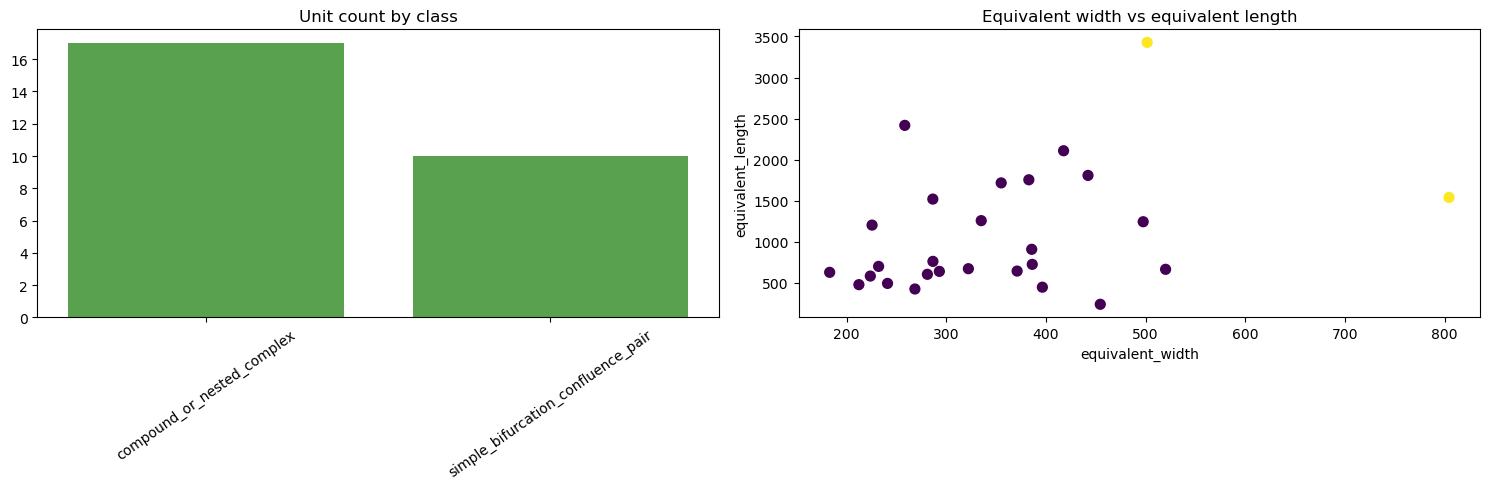

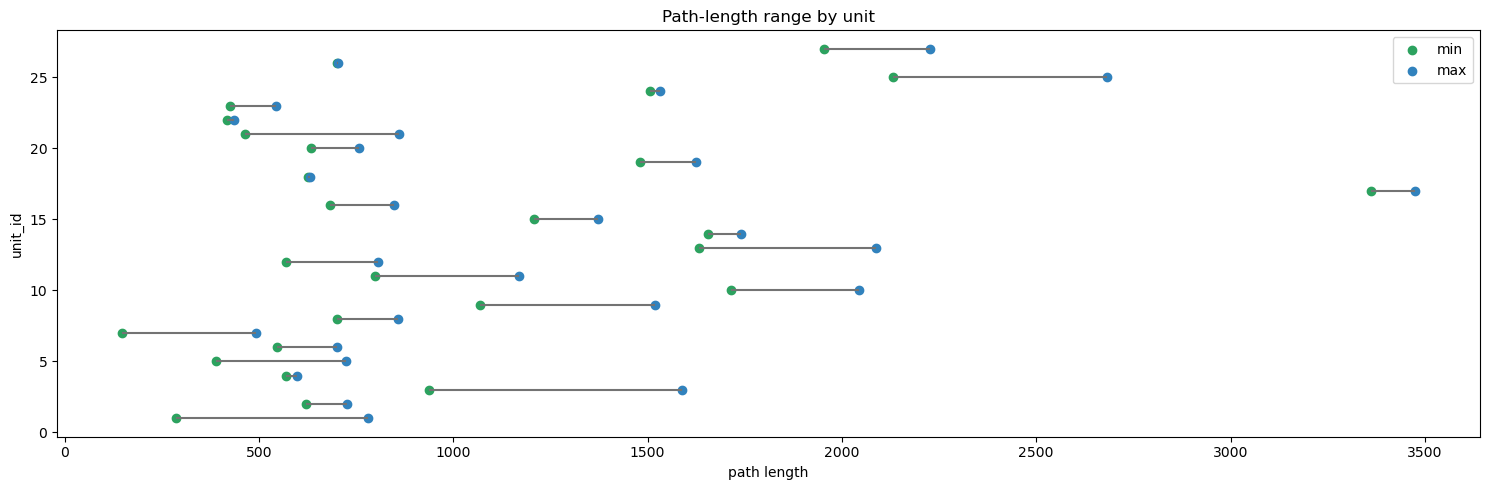

In [49]:
if unit_metrics.empty:
    print("No unit plots to show.")
else:
    class_counts = unit_metrics["class"].value_counts(dropna=False).rename_axis("class").reset_index(name="n_units")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].bar(class_counts["class"], class_counts["n_units"], color="#59a14f")
    axes[0].set_title("Unit count by class")
    axes[0].tick_params(axis="x", rotation=35)

    axes[1].scatter(unit_metrics["equivalent_width"], unit_metrics["equivalent_length"], c=unit_metrics["n_paths"], cmap="viridis", s=50)
    axes[1].set_title("Equivalent width vs equivalent length")
    axes[1].set_xlabel("equivalent_width")
    axes[1].set_ylabel("equivalent_length")

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.hlines(unit_metrics["unit_id"], unit_metrics["path_length_min"], unit_metrics["path_length_max"], color="0.45")
    ax.scatter(unit_metrics["path_length_min"], unit_metrics["unit_id"], color="#2ca25f", label="min")
    ax.scatter(unit_metrics["path_length_max"], unit_metrics["unit_id"], color="#3182bd", label="max")
    ax.set_title("Path-length range by unit")
    ax.set_xlabel("path length")
    ax.set_ylabel("unit_id")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [50]:
if summary.empty:
    print("No units detected for this network.")
else:
    class_counts = summary["class"].value_counts(dropna=False).rename_axis("class").reset_index(name="n_units")
    metrics_table = pd.DataFrame(
        {
            "metric": [
                "n_units",
                "n_unique_bifurcations",
                "n_unique_confluences",
                "min_n_paths",
                "max_n_paths",
                "median_n_paths",
                "min_path_length_min",
                "max_path_length_max",
            ],
            "value": [
                len(summary),
                summary["bifurcation"].nunique(),
                summary["confluence"].nunique(),
                summary["n_paths"].min(),
                summary["n_paths"].max(),
                summary["n_paths"].median(),
                summary["min_path_length"].min(),
                summary["max_path_length"].max(),
            ],
        }
    )

    display(class_counts)
    display(metrics_table)

,class,n_units
0,compound_or_nested_complex,17
1,simple_bifurcation_confluence_pair,10


,metric,value
0,n_units,27.000000
1,n_unique_bifurcations,27.000000
2,n_unique_confluences,27.000000
3,min_n_paths,2.000000
4,max_n_paths,3.000000
5,median_n_paths,2.000000
6,min_path_length_min,147.330582
7,max_path_length_max,3475.392233


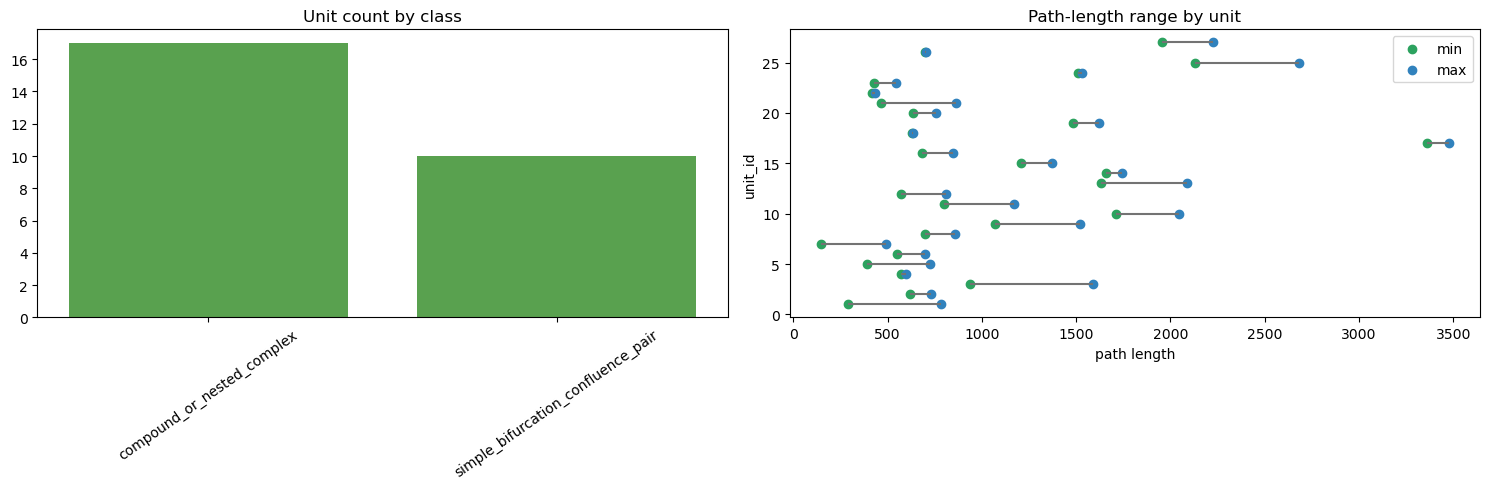

In [51]:
if summary.empty:
    print("No unit plots to show.")
else:
    class_counts = summary["class"].value_counts(dropna=False).rename_axis("class").reset_index(name="n_units")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].bar(class_counts["class"], class_counts["n_units"], color="#59a14f")
    axes[0].set_title("Unit count by class")
    axes[0].tick_params(axis="x", rotation=35)

    axes[1].hlines(summary["unit_id"], summary["min_path_length"], summary["max_path_length"], color="0.45")
    axes[1].scatter(summary["min_path_length"], summary["unit_id"], color="#2ca25f", label="min")
    axes[1].scatter(summary["max_path_length"], summary["unit_id"], color="#3182bd", label="max")
    axes[1].set_title("Path-length range by unit")
    axes[1].set_xlabel("path length")
    axes[1].set_ylabel("unit_id")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [52]:
def hierarchy_lines(nodes, indent=0):
    lines = []
    for node in nodes:
        lines.append(
            "  " * indent
            + f"unit {node['unit_id']}: bif={node['bifurcation']}, conf={node['confluence']}, paths={node['n_paths']}, class={node['class']}"
        )
        lines.extend(hierarchy_lines(node["children"], indent + 1))
    return lines

if hierarchy:
    print("\n".join(hierarchy_lines(hierarchy)))
else:
    print("Hierarchy is empty.")

NameError: name 'hierarchy' is not defined

In [ ]:
# tejedor 

# 4

In [3]:
from pathlib import Path
import sys
from importlib import reload

candidate_roots = [Path.cwd().resolve()]
candidate_roots.extend(candidate_roots[0].parents)
REPO_ROOT = next(path for path in candidate_roots if (path / "hierarchy_level_definition").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import hierarchy_level_definition.metrics.unit_metrics as unit_metrics_module
import hierarchy_level_definition.metrics as metrics_package
reload(unit_metrics_module)
reload(metrics_package)

from hierarchy_level_definition.metrics import compute_unit_metrics, summarize_by_hierarchy_level


In [4]:
summary, unit_metrics, path_metrics = compute_unit_metrics(
    links_path,
    nodes_path,
    pixel_width_fields=["wid_pix"],
    pixel_width_percentiles=(5, 50, 95),
    use_pixel_widths_for_extremes=True,
)


In [5]:
hierarchy_level_metrics = summarize_by_hierarchy_level(unit_metrics)
display(hierarchy_level_metrics)


,collapse_level,n_units,n_compound_units,n_leaf_units,mean_equivalent_width,median_equivalent_width,sum_equivalent_width,mean_equivalent_length,median_equivalent_length,mean_elongation,median_elongation,mean_n_paths,mean_n_valid_paths,mean_effective_n_paths_width,mean_width_evenness,mean_largest_path_width_fraction,mean_topologic_complexity_score,mean_dynamic_proxy_complexity_score,width_weighted_mean_elongation,width_weighted_mean_effective_n_paths_width,width_weighted_mean_width_evenness,width_weighted_mean_topologic_complexity_score,width_weighted_mean_dynamic_proxy_complexity_score
0,0,25,0,25,330.374265,322.208836,8259.356620,986.634854,701.378428,3.111177,2.501807,2.0,2.0,1.887923,0.913452,0.636345,1.722716,0.913452,2.986416,1.864820,0.895379,1.619567,0.895379
1,1,2,2,0,653.003203,653.003203,1306.006406,2484.149821,2484.149821,4.374438,4.374438,3.0,3.0,2.837122,0.948289,0.475401,3.178054,0.948289,3.804192,2.807884,0.938902,3.178054,0.938902


In [ ]:

from hierarchy_level_definition.collapse_decisions import (
    compute_collapse_decisions_from_unit_metrics,
    rank_unit_collapse_priority,
    build_constrained_merge_tree,
    summarize_group_count_selection,
)

collapse_ranking, merge_tree, bubble_summary = compute_collapse_decisions_from_unit_metrics(unit_metrics)
group_count_summary = summarize_group_count_selection(merge_tree)
selected = group_count_summary.loc[group_count_summary["is_optimal_n_groups"]]


In [ ]:
import ast
# path_metrics[['path_id', 'node_links']]

groups = []
for i, g in  merge_tree[merge_tree["n_groups"] == 3].iterrows():
    units = g['unit_ids']
    units = ast.literal_eval(units)

    pu = []
    for u in units:
    #     # print(u)
        il = path_metrics.loc[path_metrics['unit_id'] == u, 'id_links'].to_list()
        p = []
        for x in il:
            if len(x)> 2:
                x = ast.literal_eval(x)
                for y in x:
                    p.append(int(y))
            else:
                p.append(int(x))
        pu.extend(p)
    print(pu)
    groups.append(pu)

# Plots

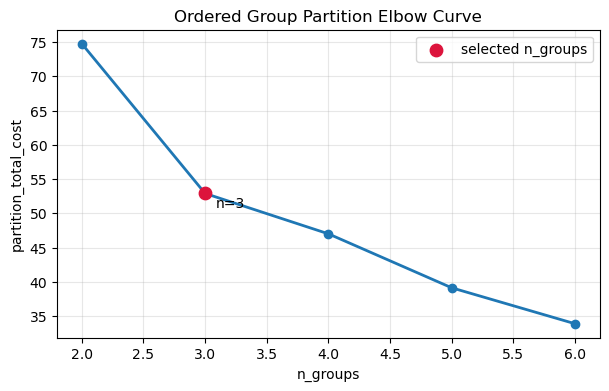

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    group_count_summary["n_groups"],
    group_count_summary["partition_total_cost"],
    marker="o",
    linewidth=2,
)

if not selected.empty:
    ax.scatter(
        selected["n_groups"],
        selected["partition_total_cost"],
        color="crimson",
        s=80,
        zorder=3,
        label="selected n_groups",
    )
    row = selected.iloc[0]
    ax.annotate(
        f"n={int(row['n_groups'])}",
        (row["n_groups"], row["partition_total_cost"]),
        textcoords="offset points",
        xytext=(8, -10),
    )

ax.set_xlabel("n_groups")
ax.set_ylabel("partition_total_cost")
ax.set_title("Ordered Group Partition Elbow Curve")
ax.grid(alpha=0.3)
if not selected.empty:
    ax.legend()
plt.show()


In [73]:
import pandas as pd
import numpy as np
# already available from the notebook cells
# collapse_ranking
# merge_tree
# group_count_summary

optimal_n_groups = int(
    group_count_summary.loc[group_count_summary["is_optimal_n_groups"], "n_groups"].iloc[0]
)

selected_groups = (
    merge_tree.loc[merge_tree["n_groups"] == optimal_n_groups]
    .sort_values("group_index")
    .reset_index(drop=True)
)

unit_to_group = {}
for row in selected_groups.itertuples(index=False):
    for unit_id in str(row.unit_ids).split(","):
        unit_to_group[int(unit_id)] = row.group_label

plot_df = collapse_ranking.copy()
plot_df["group_label"] = plot_df["unit_id"].map(unit_to_group)
plot_df["log_equivalent_length"] = np.log1p(plot_df["equivalent_length"])

selected_groups


,n_groups,group_index,group_label,group_size,unit_ids,rank_start,rank_end,compound_bubble_ids,mean_collapse_priority_score,mean_path_disparity_width,mean_effective_n_paths_width,mean_n_valid_paths,mean_equivalent_length,mean_elongation,mean_topologic_complexity_score,within_group_cost,partition_total_cost,grouping_rule
0,3,1,G3_1,6,"5,7,20,8,12,15",1,6,"2,4,6,7,8,11",0.802885,1.168877,1.717673,2.0000,661.651435,1.509642,1.098612,10.294399,52.896337,optimal_contiguous_partition
1,3,2,G3_2,16,"22,6,23,18,1,14,10,11,2,26,4,19,13,21,9,16",7,22,"1,3,5,9,10,11,12",0.476562,1.042285,1.978607,2.0625,936.588508,2.849171,1.979769,31.546172,52.896337,optimal_contiguous_partition
2,3,3,G3_3,5,"27,3,24,25,17",23,27,"1,10,12,13",0.211538,1.008020,2.181715,2.2000,2135.769253,6.376743,2.231204,11.055766,52.896337,optimal_contiguous_partition


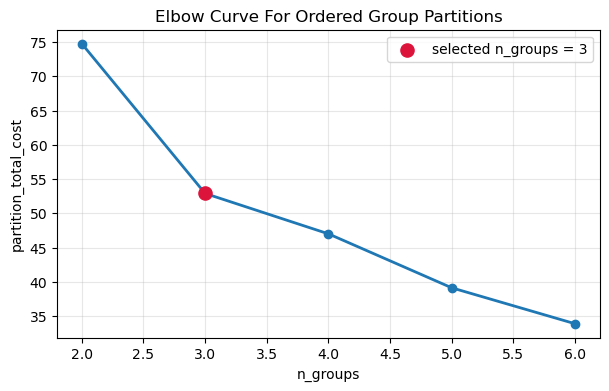

In [74]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    group_count_summary["n_groups"],
    group_count_summary["partition_total_cost"],
    marker="o",
    linewidth=2,
)

selected = group_count_summary.loc[group_count_summary["is_optimal_n_groups"]]
if not selected.empty:
    row = selected.iloc[0]
    ax.scatter(
        row["n_groups"],
        row["partition_total_cost"],
        color="crimson",
        s=90,
        zorder=3,
        label=f"selected n_groups = {int(row['n_groups'])}",
    )

ax.set_xlabel("n_groups")
ax.set_ylabel("partition_total_cost")
ax.set_title("Elbow Curve For Ordered Group Partitions")
ax.grid(alpha=0.3)
ax.legend()
plt.show()


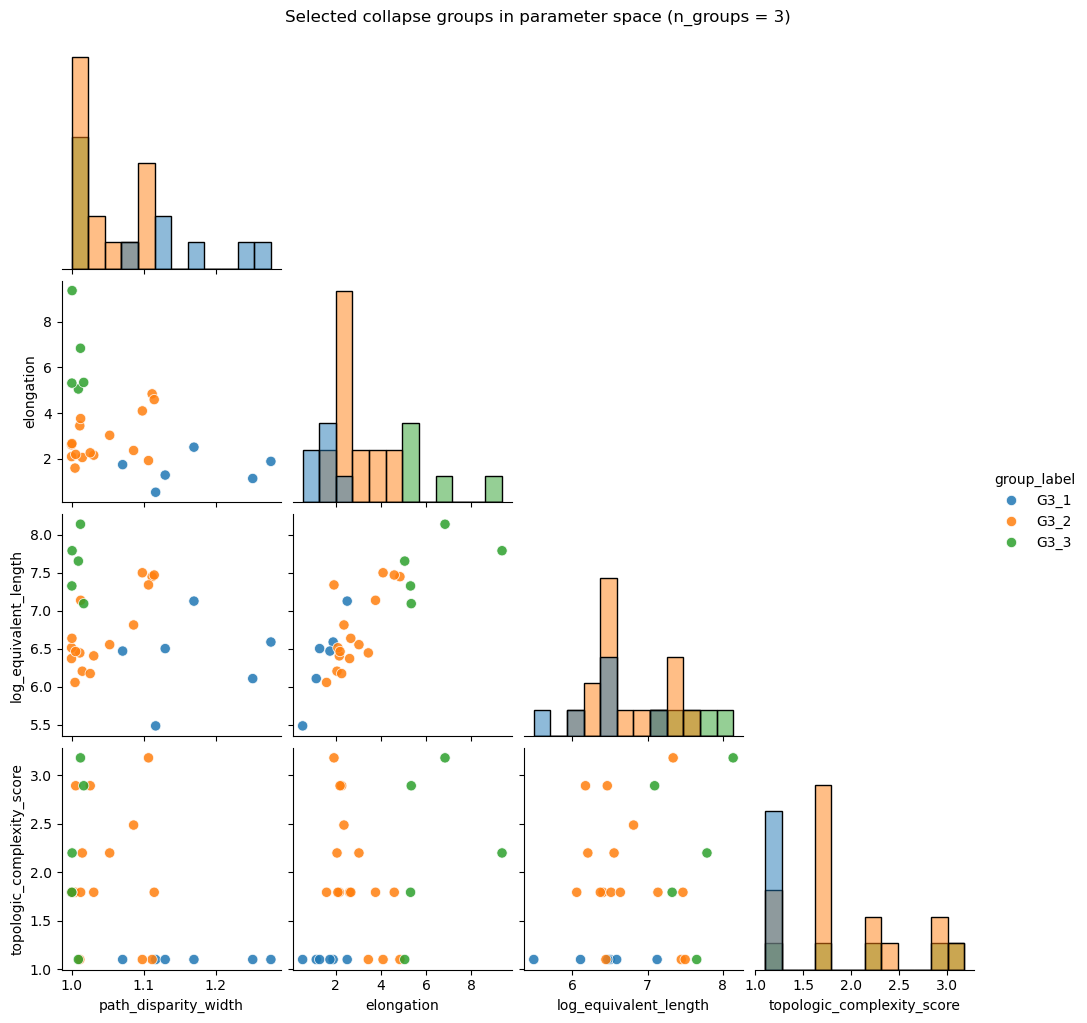

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    "path_disparity_width",
    "elongation",
    "log_equivalent_length",
    "topologic_complexity_score",
]

pair = sns.pairplot(
    plot_df[cols + ["group_label"]],
    vars=cols,
    hue="group_label",
    corner=True,
    diag_kind="hist",
    plot_kws={"s": 55, "alpha": 0.85},
    diag_kws={"bins": 12},
)

pair.fig.suptitle(
    f"Selected collapse groups in parameter space (n_groups = {optimal_n_groups})",
    y=1.02,
)
plt.show()


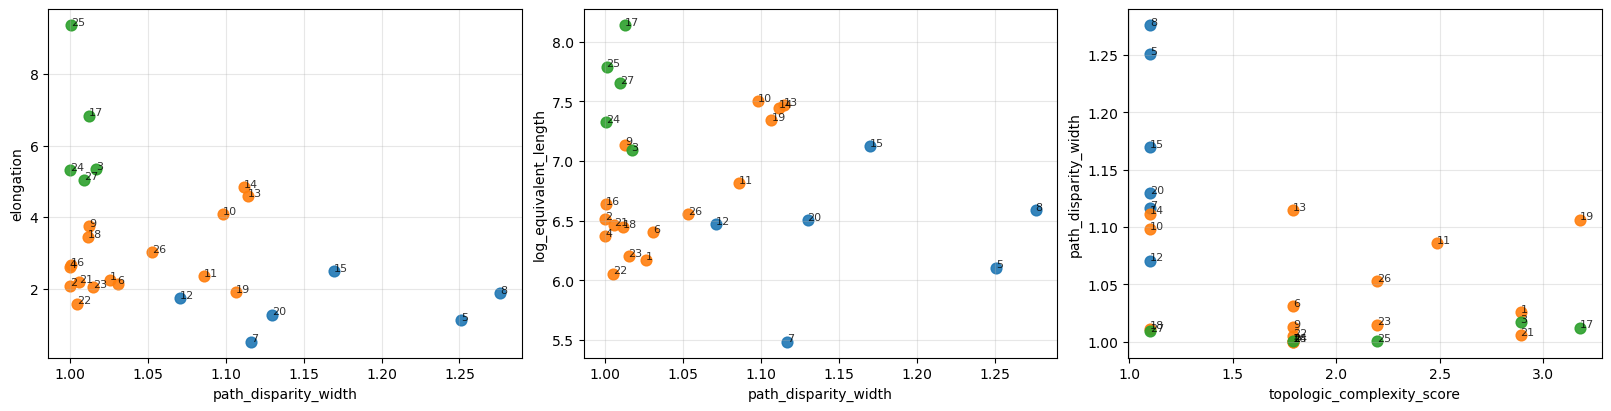

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

pairs = [
    ("path_disparity_width", "elongation"),
    ("path_disparity_width", "log_equivalent_length"),
    ("topologic_complexity_score", "path_disparity_width"),
]

palette = sns.color_palette("tab10", n_colors=plot_df["group_label"].nunique())
color_map = dict(zip(sorted(plot_df["group_label"].dropna().unique()), palette))

for ax, (xcol, ycol) in zip(axes, pairs):
    for row in plot_df.itertuples(index=False):
        ax.scatter(
            getattr(row, xcol),
            getattr(row, ycol),
            color=color_map[row.group_label],
            s=60,
            alpha=0.9,
        )
        ax.text(
            getattr(row, xcol),
            getattr(row, ycol),
            str(row.unit_id),
            fontsize=8,
            alpha=0.8,
        )
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.grid(alpha=0.3)

plt.show()


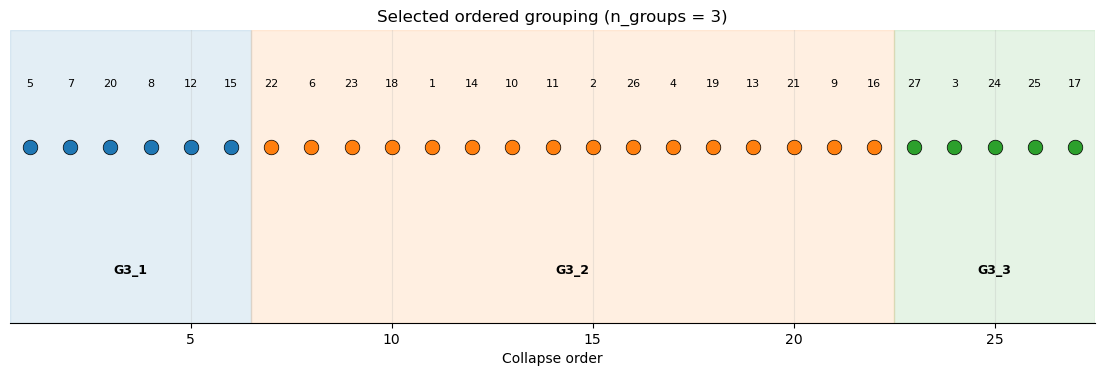

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 3.8))

group_order = selected_groups["group_label"].tolist()
group_palette = sns.color_palette("tab10", n_colors=len(group_order))
color_map = dict(zip(group_order, group_palette))

x = plot_df["collapse_order_global"]
y = [1] * len(plot_df)

for row in plot_df.itertuples(index=False):
    ax.scatter(
        row.collapse_order_global,
        1,
        s=110,
        color=color_map[row.group_label],
        edgecolor="black",
        linewidth=0.5,
        zorder=3,
    )
    ax.text(
        row.collapse_order_global,
        1.06,
        str(row.unit_id),
        ha="center",
        va="bottom",
        fontsize=8,
    )

for row in selected_groups.itertuples(index=False):
    ax.axvspan(
        row.rank_start - 0.5,
        row.rank_end + 0.5,
        color=color_map[row.group_label],
        alpha=0.12,
        zorder=1,
    )
    ax.text(
        (row.rank_start + row.rank_end) / 2,
        0.88,
        row.group_label,
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold",
    )

ax.set_xlim(0.5, plot_df["collapse_order_global"].max() + 0.5)
ax.set_ylim(0.82, 1.12)
ax.set_yticks([])
ax.set_xlabel("Collapse order")
ax.set_title(f"Selected ordered grouping (n_groups = {optimal_n_groups})")
ax.grid(axis="x", alpha=0.25)
sns.despine(left=True)
plt.show()


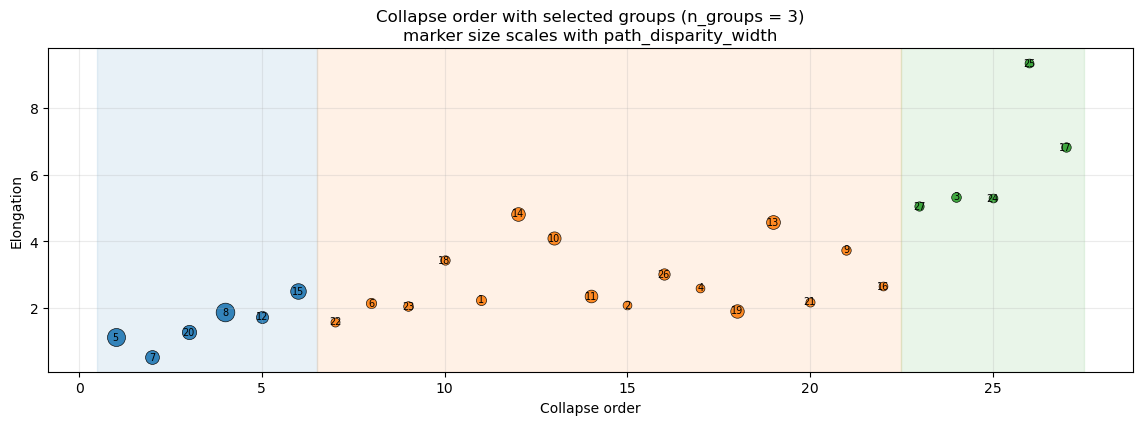

In [79]:
fig, ax = plt.subplots(figsize=(14, 4.2))

sizes = 40 + 140 * (
    plot_df["path_disparity_width"] - plot_df["path_disparity_width"].min()
) / (
    plot_df["path_disparity_width"].max() - plot_df["path_disparity_width"].min()
)

for row, size in zip(plot_df.itertuples(index=False), sizes):
    ax.scatter(
        row.collapse_order_global,
        row.elongation,
        s=size,
        color=color_map[row.group_label],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.9,
    )
    ax.text(
        row.collapse_order_global,
        row.elongation,
        str(row.unit_id),
        fontsize=7,
        ha="center",
        va="center",
    )

for row in selected_groups.itertuples(index=False):
    ax.axvspan(
        row.rank_start - 0.5,
        row.rank_end + 0.5,
        color=color_map[row.group_label],
        alpha=0.10,
        zorder=0,
    )

ax.set_xlabel("Collapse order")
ax.set_ylabel("Elongation")
ax.set_title(
    f"Collapse order with selected groups (n_groups = {optimal_n_groups})\n"
    "marker size scales with path_disparity_width"
)
ax.grid(alpha=0.25)
plt.show()


In [122]:
path = '/Users/6256481/Code/river-hierarchy/SWORD_gauge_match/outputs/'
D = gpd.read_file(path + 'hierarchy_examples_filtered_subdaily_manual_updates.gpkg', layer = 'subdaily_station_summary')

In [123]:
d = D[D['subdaily_found'] == True]
# d.to_file(path + 'hierarchy_examples_filtered_subdaily_manual_updates_filtered.gpkg', layer = 'subdaily_station_summary')

In [97]:
D['example_ids'].unique()

array(['30', '11', '9', '5', '13', '10', '12', '6', '7', '4', '3', '56',
       '54', '55', '45', '46', '41', '42', '52', '2', '14', '15', '22',
       '19', '18', '27', '21', '48', '47', '36', '37'], dtype=object)

In [124]:
d.loc[(d['example_ids'] == '36') & (d['subdaily_found'] == True), 'example_ids'] = 41
d = d[(d['example_ids'] != '7')]

In [126]:
d.to_file(path + 'hierarchy_examples_filtered_subdaily_manual_updates_final.gpkg', layer = 'subdaily_station_summary')

In [103]:
D = D.to_crs('EPSG:3857')

In [119]:
bounds = []
for ex in D['example_ids'].unique():
    
    d = D[D['example_ids'] == ex]
    # print(d)
    bounds.append(d.total_bounds)
    print(ex, d.total_bounds)
# total_bounds returns: [minx, miny, maxx, maxy]
bounds_df = pd.DataFrame(
    bounds,
    columns=["minx", "miny", "maxx", "maxy"]
)

bounds_df["indicator"] = D['example_ids'].unique()

30 [2821949.09160948 5408361.23322365 3034569.31902464 5485582.07211476]
11 [-6352045.9919513   -152589.04763367 -6328724.55863011  -111080.20276309]
9 [-6473818.38293006  -819295.52878837 -6270070.31893113  -514362.86904811]
5 [-5686411.09675292 -1679152.69667684 -5631096.44177774 -1336229.79358162]
13 [-6804248.02745174   202791.47915991 -6742744.00878845   382957.43198829]
10 [-7276365.11985509 -1085344.52975043 -6681985.83071348  -545818.7961018 ]
12 [-6453714.0828928   -122525.7669146  -6351545.05424273   -77335.54513776]
6 [-5639723.70231422 -1302276.16925274 -5357773.69603302  -628231.91202185]
4 [-4486943.5834554  -1820779.00786766 -4399747.02631703 -1798736.39017091]
3 [-4647835.86988873 -2481931.59673685 -4597528.36560944 -2468989.76818379]
56 [-9332283.60710447  6679975.57608455 -9236178.15111791  6773735.46721211]
54 [-12774797.67167486   7041567.72242271 -12633148.07242005
   7082992.08617696]
55 [-12201854.0636804    6867937.37455474 -11774076.63765492
   7079144.88666542

In [121]:
bounds_df.to_csv(path + 'hierarchy_examples_filtered_subdaily_total_bounds.csv')

In [129]:
p = '/Users/6256481/Code/river-hierarchy/network_variants/output/sarl03_indep/states/S001_unit_5/rapid/prep/'
d = pd.read_csv(p + 'rapid_link_attributes.csv')

In [157]:
[x for x in d.columns if 'wid' in x]

['wid_pix',
 'wid',
 'wid_adj',
 'wid_med',
 'wid_pix_total',
 'wid_pix_wet',
 'wid_pix_dry',
 'wid_adj_total',
 'wid_med_total',
 'wid_p05_total',
 'wid_p50_total',
 'wid_p95_total',
 'wid_mean_total',
 'wid_adj_wet',
 'wid_med_wet',
 'wid_p05_wet',
 'wid_p50_wet',
 'wid_p95_wet',
 'wid_mean_wet',
 'wid_adj_dry',
 'wid_med_dry',
 'wid_p05_dry',
 'wid_p50_dry',
 'wid_p95_dry',
 'wid_mean_dry',
 'rapid_width_source_field',
 'rapid_width_m_raw',
 'rapid_width_adjusted',
 'rapid_width_m']

In [136]:
d[['id_link', 'link_length_m', 'slope_used', 'rapid_k']].sort_values('slope_used')

,id_link,link_length_m,slope_used,rapid_k
54,78,6188.369030,0.000031,38314.228116
45,13,914.910281,0.000046,4016.712790
44,14,570.863172,0.000073,1575.489681
67,16,458.453727,0.000074,2614.127737
50,23,2503.449973,0.000100,15059.874404
...,...,...,...,...
73,5,306.301543,0.001437,393.810696
76,1,875.167541,0.001484,1036.415263
75,3,196.716528,0.001569,204.271847
77,4,784.041682,0.002051,800.564711


In [171]:
max(1, round(650 / 500))

1

In [163]:
x = 0.005
dd = d.copy()
dd.loc[dd['link_length_m'] > 2000, 'link_length_m'] =2000
# rk = d.loc[(d['link_length_m'] <6000) &(d['link_length_m'] >250), 'rapid_k']
rk = (3/5)*0.35*(dd['link_length_m'] / np.sqrt(dd['slope_used'])) * (20**(2/3) / dd['wid_adj_wet'] **(2/3))


dtmin = np.max(2*x*rk)
dtmax = np.min(2*rk*(1-x))
print(dtmin, dtmax)

145.81805404671653 155.02789007720855


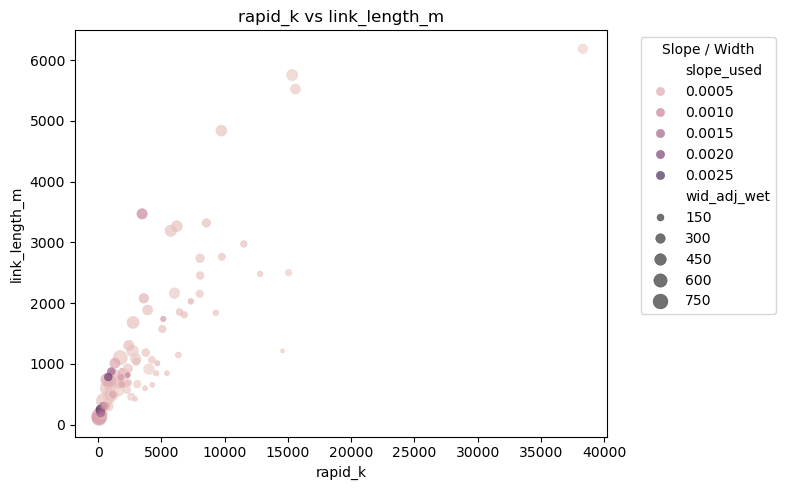

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=d,
    x="rapid_k",
    y="link_length_m",
    hue="slope_used",
    size="wid_adj_wet",
    sizes=(10, 120),
    alpha=0.7,
    edgecolor=None
)

# plt.ylim(0, 1000)
# plt.xlim(0, 7000)

plt.xlabel("rapid_k")
plt.ylabel("link_length_m")
plt.title("rapid_k vs link_length_m")

plt.legend(
    title="Slope / Width",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [259]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.io import netcdf_file

exp_dir = Path("/Users/6256481/Code/river-hierarchy/network_variants/output/sarl03_indep")
run_registry = pd.read_csv(exp_dir / "rapid_run_registry.csv")

series_by_state = {}

for row in run_registry.itertuples(index=False):
    if row.status != "ran":
        continue

    qout_path = Path(row.qout_nc)
    prep_manifest_path = Path(row.rapid_prep_dir) / "rapid_prep_manifest.json"

    with netcdf_file(qout_path, "r", mmap=False) as ds:
        rivid = np.array(ds.variables["rivid"].data).copy()
        time = np.array(ds.variables["time"].data).copy()
        qout = np.array(ds.variables["Qout"].data).copy()

    riv = pd.read_csv(Path(row.rapid_prep_dir) / "riv.csv", header=None)[0].to_numpy()
    final_reach_id = int(riv[-1])
    final_idx = int(np.where(rivid == final_reach_id)[0][0])

    ts = pd.DataFrame(
        {
            "time_seconds": time,
            "q_cms": qout[:, final_idx],
        }
    )
    ts["state_id"] = row.state_id
    ts["final_reach_id"] = final_reach_id

    series_by_state[row.state_id] = ts

# example: one state
print(series_by_state["S001_unit_5"].head())

# combine all states into one long table
all_outlet_ts = pd.concat(series_by_state.values(), ignore_index=True)
print(all_outlet_ts.head())


   time_seconds  q_cms     state_id  final_reach_id
0             0    0.0  S001_unit_5             796
1          1800    0.0  S001_unit_5             796
2          3600    0.0  S001_unit_5             796
3          5400    0.0  S001_unit_5             796
4          7200    0.0  S001_unit_5             796
   time_seconds  q_cms     state_id  final_reach_id
0             0    0.0  S001_unit_5             796
1          1800    0.0  S001_unit_5             796
2          3600    0.0  S001_unit_5             796
3          5400    0.0  S001_unit_5             796
4          7200    0.0  S001_unit_5             796


In [283]:
q

280    1950.225047
281    1960.378994
282    1970.266557
283    1979.833809
284    1989.085122
          ...     
395    2014.172132
396    2000.775394
397    1987.759158
398    1975.125017
399    1962.866671
Name: q_cms, Length: 120, dtype: float64

In [ ]:
fig = go.Figure()


for k in series_by_state.keys():
    u = series_by_state[k]
    start = 250
    end = 450
    t = np.asarray(u["time_seconds"][start:end], dtype=np.float64).copy()
    q = np.asarray(u["q_cms"][start:end], dtype=np.float64).copy()
    state_name = u['state_id'].iloc[0]
    # plt.scatter(t, q)
    fig.add_trace(go.Scatter(
        x=t,
        y=q,
        mode="markers",
        name=state_name,
        hovertemplate=f"{state_name}" +"<br>time: %{x}<br>discharge: %{y}<extra></extra>"
    ))

# fig.add_trace(go.Scatter(
#     x=p2["time"],
#     y=p2["discharge"],
#     mode="markers",
#     name=f"{p1['station_key'].iloc[0]}",
#     hovertemplate=f"{p2['station_key'].iloc[0]}"+"<br>time: %{x}<br>discharge: %{y}<extra></extra>"
# ))

fig.update_layout(
    title="Discharge over Time",
    xaxis_title="time",
    yaxis_title="discharge"
)

fig.show('browser')

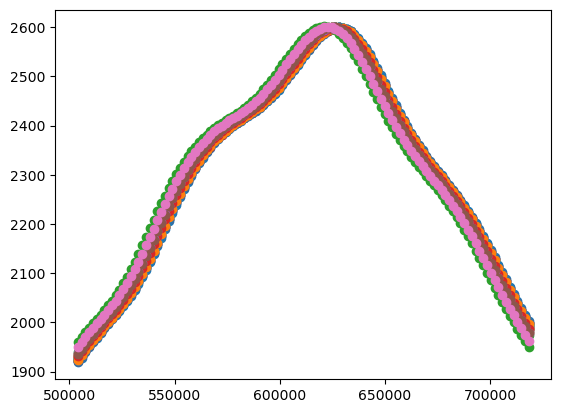

In [276]:
for k in series_by_state.keys():
    u = series_by_state[k]
    # print()
    start = 280
    end = 400
    t = u['time_seconds'][start:end]
    q = u['q_cms'][start:end]
    plt.scatter(t, q)
# plt.ylim(1.596326e-306, 1.596326e-305)


In [233]:
p = '/Users/6256481/Code/river-hierarchy/SWORD_gauge_match/outputs/'
df_ex = gpd.read_file(p +'hierarchy_examples_filtered_subdaily_manual_updates_final.gpkg')

In [205]:
dfsub = pd.read_parquet(p + f'subdaily_values/BR/subdaily_timeseries.parquet')

In [234]:
stations = df_ex.loc[df_ex['example_ids'] == '3', 'station_key'].to_list()
stations

['BR:3652880', 'BR:3652890']

In [211]:
stat1 = dfsub[dfsub['station_key'] == stations[0]]
stat2 = dfsub[dfsub['station_key'] == stations[1]]

In [224]:
stat1[stat1['time'] > '2021-08-01 00:00:00+0000']

,station_key,station_id,country,time,discharge,variable,source_function,provider,provider_station_id,provider_series_id,provider_series_name,unit_of_measure,raw_discharge,raw_unit_of_measure,unit_normalized,window_strategy
5402806,BR:3652880,3652880,BR,2021-08-01 00:15:00+00:00,171.10,discharge,brazil_ana,brazil_ana,58880001,58880001,telemetric_vazao,m3/s,171.10,m3/s,True,latest_10y
5402807,BR:3652880,3652880,BR,2021-08-01 00:30:00+00:00,171.10,discharge,brazil_ana,brazil_ana,58880001,58880001,telemetric_vazao,m3/s,171.10,m3/s,True,latest_10y
5402808,BR:3652880,3652880,BR,2021-08-01 00:45:00+00:00,171.10,discharge,brazil_ana,brazil_ana,58880001,58880001,telemetric_vazao,m3/s,171.10,m3/s,True,latest_10y
5402809,BR:3652880,3652880,BR,2021-08-01 01:00:00+00:00,171.10,discharge,brazil_ana,brazil_ana,58880001,58880001,telemetric_vazao,m3/s,171.10,m3/s,True,latest_10y
5402810,BR:3652880,3652880,BR,2021-08-01 01:15:00+00:00,171.10,discharge,brazil_ana,brazil_ana,58880001,58880001,telemetric_vazao,m3/s,171.10,m3/s,True,latest_10y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5568500,BR:3652880,3652880,BR,2026-04-30 10:00:00+00:00,363.17,discharge,brazil_ana,brazil_ana,58880001,58880001,telemetric_vazao,m3/s,363.17,m3/s,True,latest_10y
5568501,BR:3652880,3652880,BR,2026-04-30 10:15:00+00:00,363.17,discharge,brazil_ana,brazil_ana,58880001,58880001,telemetric_vazao,m3/s,363.17,m3/s,True,latest_10y
5568502,BR:3652880,3652880,BR,2026-04-30 10:30:00+00:00,363.17,discharge,brazil_ana,brazil_ana,58880001,58880001,telemetric_vazao,m3/s,363.17,m3/s,True,latest_10y
5568503,BR:3652880,3652880,BR,2026-04-30 10:45:00+00:00,363.17,discharge,brazil_ana,brazil_ana,58880001,58880001,telemetric_vazao,m3/s,363.17,m3/s,True,latest_10y


In [258]:
import pandas as pd

tstart = "2023-02-12 00:00:00+0000"
tend   = "2023-02-23 00:00:00+0000"

p1 = stat1.copy()
p1["time"] = pd.to_datetime(p1["time"], utc=True)

p1 = p1[(p1["time"] > tstart) & (p1["time"] < tend)].copy()
p1 = p1.sort_values("time")

# set time index
p1i = p1.set_index("time")

# 30-minute discharge series
p1_30min = (
    p1i["discharge"]
    .resample("30min")
    .mean()
    .interpolate("time")
    .reset_index()
)

# hourly discharge series
p1_1h = (
    p1i["discharge"]
    .resample("1h")
    .mean()
    .interpolate("time")
    .reset_index()
)

p1_30min.to_csv(p + "subdaily_values/BR/Ex_03_2023_02_30min.csv", index=False)
p1_1h.to_csv(p + "subdaily_values/BR/Ex_03_2023_02_1h.csv", index=False)


tstart = '2023-02-12 00:00:00+0000'
tend   = '2023-02-23 00:00:00+0000'

p1 = stat1.copy()
p2 = stat2.copy()

p1 = p1[(p1['time'] > tstart) & (p1['time'] < tend)]
p2 = p2[(p2['time'] > tstart) & (p2['time'] < tend)]

p1[['time', 'discharge']].to_csv(p+f"subdaily_values/BR/Ex_03_2023_02.csv")


In [ ]:
import plotly.graph_objects as go

import plotly.express as px
import pandas as pd
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=p1["time"],
    y=p1["discharge"],
    mode="markers",
    name=p1['station_key'].iloc[0],
    hovertemplate=f"{p1['station_key'].iloc[0]}" +"<br>time: %{x}<br>discharge: %{y}<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=p2["time"],
    y=p2["discharge"],
    mode="markers",
    name=f"{p1['station_key'].iloc[0]}",
    hovertemplate=f"{p2['station_key'].iloc[0]}"+"<br>time: %{x}<br>discharge: %{y}<extra></extra>"
))

fig.update_layout(
    title="Discharge over Time",
    xaxis_title="time",
    yaxis_title="discharge"
)

fig.show('browser')

In [257]:
p1[['time', 'discharge']].to_csv(p+f"subdaily_values/BR/Ex_03_2023_02.csv")

In [256]:
p1t = p1.copy()

dt = p1t["time"].diff()
bad_idx = dt[dt > pd.Timedelta("15min")].index

for i in bad_idx[:10]:
    print(p1t.loc[i-2:i+2, ["time", "discharge"]])
    print()
